In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [184]:
freq = pd.read_csv("data/raw/freMTPL2freq.csv")
sev = pd.read_csv("data/raw/freMTPL2sev.csv")

print(freq.shape)
print(sev.shape)

freq.head()

(678013, 12)
(26639, 2)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


In [185]:
freq.columns

Index(['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'],
      dtype='object')

In [186]:
sev.columns

Index(['IDpol', 'ClaimAmount'], dtype='object')

## Build the Policy-Level Analytics Dataset

The raw public insurance dataset is split into a policy-level frequency table and a claim-level severity table. To support product analytics, I first aggregate claim amounts by policy ID, then merge the claim summary into the policy table. This prevents duplicate policy rows when a policy has multiple claims.

The resulting policy master table contains exposure, rating attributes, claim outcomes, simulated earned premium, telematics program fields, and retention indicators. This table becomes the foundation for rating-feature reporting, telematics program analysis, and implementation testing.

Steps: Load raw data, Aggregate claim-level data, Merge policy + claim summary, Create insurance KPIs, Create rating-feature tiers, Simulate premium, Simulate telematics program, Simulate renewal, Export processed files.

In [187]:
# summarize claims by policy
claims_summary = (
    sev.groupby("IDpol")
    .agg(
        claim_record_count=("ClaimAmount", "count"),
        total_claim_amount=("ClaimAmount", "sum"),
        avg_claim_amount=("ClaimAmount", "mean"),
        max_claim_amount=("ClaimAmount", "max")
    )
    .reset_index()
)

claims_summary.head()

,IDpol,claim_record_count,total_claim_amount,avg_claim_amount,max_claim_amount
0,139,1,303.00,303.00,303.00
1,190,1,1981.84,1981.84,1981.84
2,414,1,1456.55,1456.55,1456.55
3,424,2,10834.00,5417.00,9844.36
4,463,1,3986.67,3986.67,3986.67


In [188]:
# merge policy data with claim summary
policy_master = freq.merge(
    claims_summary,
    on="IDpol",
    how="left"
)

policy_master[["claim_record_count", "total_claim_amount", "avg_claim_amount", "max_claim_amount"]] = (
    policy_master[["claim_record_count", "total_claim_amount", "avg_claim_amount", "max_claim_amount"]]
    .fillna(0)
)

policy_master.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,claim_record_count,total_claim_amount,avg_claim_amount,max_claim_amount
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82,0.0,0.0,0.0,0.0
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82,0.0,0.0,0.0,0.0
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22,0.0,0.0,0.0,0.0
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72,0.0,0.0,0.0,0.0
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72,0.0,0.0,0.0,0.0


In [189]:
# Create core insurance KPIs
policy_master["has_claim"] = (policy_master["ClaimNb"] > 0).astype(int)

policy_master["claim_frequency"] = policy_master["ClaimNb"] / policy_master["Exposure"]

policy_master["claim_severity"] = np.where(
    policy_master["ClaimNb"] > 0,
    policy_master["total_claim_amount"] / policy_master["ClaimNb"],
    0
)

policy_master["pure_premium"] = policy_master["total_claim_amount"] / policy_master["Exposure"]

policy_master[
    ["IDpol", "Exposure", "ClaimNb", "total_claim_amount", 
     "has_claim", "claim_frequency", "claim_severity", "pure_premium"]
].head()

,IDpol,Exposure,ClaimNb,total_claim_amount,has_claim,claim_frequency,claim_severity,pure_premium
0,1.0,0.10,1,0.0,1,10.000000,0.0,0.0
1,3.0,0.77,1,0.0,1,1.298701,0.0,0.0
2,5.0,0.75,1,0.0,1,1.333333,0.0,0.0
3,10.0,0.09,1,0.0,1,11.111111,0.0,0.0
4,11.0,0.84,1,0.0,1,1.190476,0.0,0.0


In [190]:
# Create rating-feature tiers
policy_master["driver_age_tier"] = pd.cut(
    policy_master["DrivAge"],
    bins=[17, 24, 34, 49, 64, 100],
    labels=["18-24", "25-34", "35-49", "50-64", "65+"]
)

policy_master["vehicle_age_tier"] = pd.cut(
    policy_master["VehAge"],
    bins=[-1, 2, 5, 10, 15, 100],
    labels=["0-2", "3-5", "6-10", "11-15", "16+"]
)

policy_master["bonus_malus_tier"] = pd.cut(
    policy_master["BonusMalus"],
    bins=[0, 75, 100, 125, 150, 350],
    labels=["Strong Bonus", "Standard Bonus", "Neutral", "Malus", "High Malus"]
)

policy_master["density_tier"] = pd.qcut(
    policy_master["Density"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

policy_master.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,...,avg_claim_amount,max_claim_amount,has_claim,claim_frequency,claim_severity,pure_premium,driver_age_tier,vehicle_age_tier,bonus_malus_tier,density_tier
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,...,0.0,0.0,1,10.000000,0.0,0.0,50-64,0-2,Strong Bonus,High
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,...,0.0,0.0,1,1.298701,0.0,0.0,50-64,0-2,Strong Bonus,High
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,...,0.0,0.0,1,1.333333,0.0,0.0,50-64,0-2,Strong Bonus,Very Low
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,...,0.0,0.0,1,11.111111,0.0,0.0,35-49,0-2,Strong Bonus,Low
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,...,0.0,0.0,1,1.190476,0.0,0.0,35-49,0-2,Strong Bonus,Low


In [191]:
# simulate earned premium 
# Because public insurance datasets usually do not include real premium, so I create a transparent simulated premium.
np.random.seed(42)

base_rate = 650

driver_age_factor = np.select(
    [
        policy_master["DrivAge"] < 25,
        policy_master["DrivAge"].between(25, 34),
        policy_master["DrivAge"].between(35, 64),
        policy_master["DrivAge"] >= 65
    ],
    [1.45, 1.15, 1.00, 1.10],
    default=1.00
)

vehicle_age_factor = np.select(
    [
        policy_master["VehAge"] <= 2,
        policy_master["VehAge"].between(3, 10),
        policy_master["VehAge"] > 10
    ],
    [1.10, 1.00, 0.95],
    default=1.00
)

bonus_malus_factor = policy_master["BonusMalus"] / 100

area_factor = policy_master["Area"].map({
    "A": 0.90,
    "B": 0.95,
    "C": 1.00,
    "D": 1.05,
    "E": 1.10,
    "F": 1.20
}).fillna(1.00)

random_noise = np.random.normal(1.00, 0.05, len(policy_master))

policy_master["earned_premium"] = (
    base_rate
    * policy_master["Exposure"]
    * driver_age_factor
    * vehicle_age_factor
    * bonus_malus_factor
    * area_factor
    * random_noise
)

policy_master["earned_premium"] = policy_master["earned_premium"].clip(lower=100)

In [192]:
# loss ratio
policy_master["loss_ratio"] = np.where(
    policy_master["earned_premium"] > 0,
    policy_master["total_claim_amount"] / policy_master["earned_premium"],
    np.nan
)

policy_master[["earned_premium", "total_claim_amount", "loss_ratio"]].head()

,earned_premium,total_claim_amount,loss_ratio
0,100.000000,0.0,0.0
1,287.040563,0.0,0.0
2,262.967671,0.0,0.0
3,100.000000,0.0,0.0
4,281.944978,0.0,0.0


In [193]:
# Simulate telematics fields
policy_master["telematics_eligible"] = (
    (policy_master["DrivAge"] >= 18) &
    (policy_master["VehAge"] <= 20) &
    (policy_master["Exposure"] > 0)
).astype(int)

# enrollment
enrollment_probability = np.where(
    policy_master["telematics_eligible"] == 1,
    0.35,
    0.00
)

policy_master["telematics_enrolled"] = np.random.binomial(
    1,
    enrollment_probability
)

# Driving score:
policy_master["driving_score"] = np.where(
    policy_master["telematics_enrolled"] == 1,
    np.random.normal(78, 12, len(policy_master)),
    np.nan
)

policy_master["driving_score"] = policy_master["driving_score"].clip(0, 100)

# Discount rule:
def assign_discount(score):
    if pd.isna(score):
        return 0.00
    elif score >= 90:
        return 0.20
    elif score >= 80:
        return 0.15
    elif score >= 70:
        return 0.08
    elif score >= 60:
        return 0.03
    else:
        return 0.00

policy_master["expected_discount_percent"] = policy_master["driving_score"].apply(assign_discount)

policy_master["premium_after_discount"] = (
    policy_master["earned_premium"] 
    * (1 - policy_master["expected_discount_percent"])
)

In [194]:
# Simulate renewal flag
base_retention = 0.78

retention_boost = np.where(policy_master["telematics_enrolled"] == 1, 0.06, 0.00)
high_loss_penalty = np.where(policy_master["loss_ratio"] > 1.0, -0.05, 0.00)

renewal_probability = base_retention + retention_boost + high_loss_penalty
renewal_probability = np.clip(renewal_probability, 0.50, 0.95)

policy_master["renewed"] = np.random.binomial(1, renewal_probability)

In [195]:
# Create separate telematics table
telematics_table = policy_master[
    [
        "IDpol",
        "telematics_eligible",
        "telematics_enrolled",
        "driving_score",
        "expected_discount_percent",
        "earned_premium",
        "premium_after_discount",
        "renewed"
    ]
].copy()

telematics_table.head()

,IDpol,telematics_eligible,telematics_enrolled,driving_score,expected_discount_percent,earned_premium,premium_after_discount,renewed
0,1.0,1,0,NaN,0.00,100.000000,100.000000,1
1,3.0,1,0,NaN,0.00,287.040563,287.040563,1
2,5.0,1,0,NaN,0.00,262.967671,262.967671,0
3,10.0,1,0,NaN,0.00,100.000000,100.000000,1
4,11.0,1,1,71.494024,0.08,281.944978,259.389380,1


In [196]:
# save processed files
policy_master.to_csv("data/processed/policy_master.csv", index=False)
claims_summary.to_csv("data/processed/claims_summary.csv", index=False)
telematics_table.to_csv("data/processed/telematics_table.csv", index=False)

## Rating Feature Analysis

### Business Question

Which rating features are associated with higher claim frequency, severity, pure premium, and loss ratio?

### Approach

I analyze key personal auto insurance rating features such as driver age, vehicle age, Bonus-Malus tier, geographic density, area, and region. For each feature, I compare policy count, exposure, claim count, claim frequency, severity, pure premium, earned premium, and loss ratio.

This mirrors a workflow where rating features are monitored to identify segments that may need further review by Product, State Management, or actuarial teams.

In [197]:
# This function calculates key risk and profitability metrics 
# grouped by any chosen driving feature, sorting the results to instantly expose the company's least profitable customer segments.
def summarize_rating_feature(df, feature_col):
    summary = (
        df.groupby(feature_col, observed=True)
        .agg(
            policies=("IDpol", "count"),
            exposure=("Exposure", "sum"),
            claims=("ClaimNb", "sum"),
            total_claim_amount=("total_claim_amount", "sum"),
            earned_premium=("earned_premium", "sum"),
            avg_premium=("earned_premium", "mean")
        )
        .reset_index()
    )

    summary["claim_frequency"] = summary["claims"] / summary["exposure"]

    summary["claim_severity"] = np.where(
        summary["claims"] > 0,
        summary["total_claim_amount"] / summary["claims"],
        0
    )

    summary["pure_premium"] = summary["total_claim_amount"] / summary["exposure"]

    summary["loss_ratio"] = np.where(
        summary["earned_premium"] > 0,
        summary["total_claim_amount"] / summary["earned_premium"],
        np.nan
    )

    return summary.sort_values("loss_ratio", ascending=False)

In [198]:
# Rating-feature summaries
driver_age_summary = summarize_rating_feature(policy_master, "driver_age_tier")
vehicle_age_summary = summarize_rating_feature(policy_master, "vehicle_age_tier")
bonus_malus_summary = summarize_rating_feature(policy_master, "bonus_malus_tier")
density_summary = summarize_rating_feature(policy_master, "density_tier")
area_summary = summarize_rating_feature(policy_master, "Area")
region_summary = summarize_rating_feature(policy_master, "Region")

display(driver_age_summary)
display(vehicle_age_summary)
display(bonus_malus_summary)
display(density_summary)

,driver_age_tier,policies,exposure,claims,total_claim_amount,earned_premium,avg_premium,claim_frequency,claim_severity,pure_premium,loss_ratio
0,18-24,30198,12489.161085,2364,11741344.21,1.091225e+07,361.356845,0.189284,4966.727669,940.122730,1.075978
4,65+,73162,47990.519831,4560,6658804.38,1.902392e+07,260.024637,0.095019,1460.264118,138.752495,0.350023
2,35-49,252126,131230.440662,12894,18265396.59,5.318139e+07,210.931804,0.098255,1416.581091,139.185668,0.343455
3,50-64,181580,102190.709449,9888,13286251.41,3.920812e+07,215.927536,0.096760,1343.674293,130.014279,0.338865
1,25-34,140947,64598.614437,6396,9957419.91,3.601047e+07,255.489411,0.099011,1556.819873,154.142933,0.276515


,vehicle_age_tier,policies,exposure,claims,total_claim_amount,earned_premium,avg_premium,claim_frequency,claim_severity,pure_premium,loss_ratio
3,11-15,134063,77990.975407,6648,17808346.08,3.256437e+07,242.903467,0.085241,2678.752419,228.338548,0.546866
2,6-10,171594,99008.916360,9846,15805071.87,4.314919e+07,251.460972,0.099446,1605.227693,159.632813,0.366289
1,3-5,132490,72040.123776,6743,10552899.23,3.086633e+07,232.971050,0.093601,1565.015458,146.486412,0.341890
0,0-2,188147,79176.055348,10904,12299662.34,3.941530e+07,209.492022,0.137718,1127.995446,155.345733,0.312053
4,16+,51719,30283.374571,1961,3443236.98,1.234097e+07,238.615699,0.064755,1755.857715,113.700571,0.279009


,bonus_malus_tier,policies,exposure,claims,total_claim_amount,earned_premium,avg_premium,claim_frequency,claim_severity,pure_premium,loss_ratio
3,Malus,598,277.924712,110,411675.38,3.046719e+05,509.484789,0.395791,3742.503455,1481.247841,1.351209
4,High Malus,209,95.128197,54,132676.41,1.238690e+05,592.674447,0.567655,2456.970556,1394.711711,1.071103
2,Neutral,6987,3198.266094,1178,2015577.77,2.988160e+06,427.674209,0.368325,1711.016783,630.209529,0.674521
1,Standard Bonus,111051,44820.338260,7090,19424278.04,3.215734e+07,289.572705,0.158187,2739.672502,433.380889,0.604039
0,Strong Bonus,559168,310107.788200,27670,37925008.90,1.227621e+08,219.544247,0.089227,1370.618319,122.296216,0.308931


,density_tier,policies,exposure,claims,total_claim_amount,earned_premium,avg_premium,claim_frequency,claim_severity,pure_premium,loss_ratio
1,Low,134178,74104.379570,6743,13954250.52,3.097975e+07,230.885482,0.090993,2069.442462,188.305342,0.450431
3,High,137845,69486.203925,7855,14010243.86,3.313649e+07,240.389462,0.113044,1783.608384,201.626266,0.422804
4,Very High,133252,61458.720818,7660,11906386.01,3.184710e+07,238.999065,0.124637,1554.358487,193.729805,0.373861
0,Very Low,137340,81409.009565,6753,10081880.20,3.083625e+07,224.524883,0.082952,1492.948349,123.842315,0.326949
2,Medium,135398,72041.131585,7091,9956455.91,3.153657e+07,232.917533,0.098430,1404.097576,138.205157,0.315711


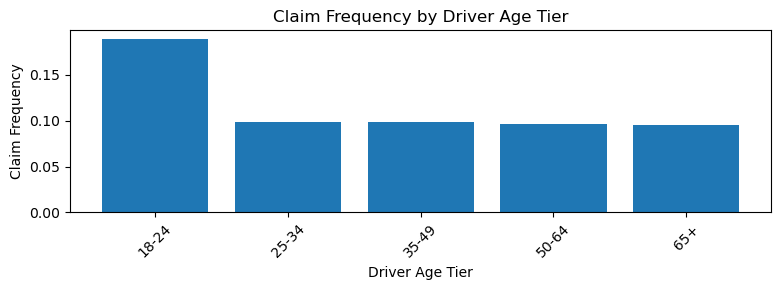

In [199]:
driver_age_plot = driver_age_summary.sort_values("driver_age_tier")

plt.figure(figsize=(8, 3))
plt.bar(driver_age_plot["driver_age_tier"].astype(str), driver_age_plot["claim_frequency"])
plt.title("Claim Frequency by Driver Age Tier")
plt.xlabel("Driver Age Tier")
plt.ylabel("Claim Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

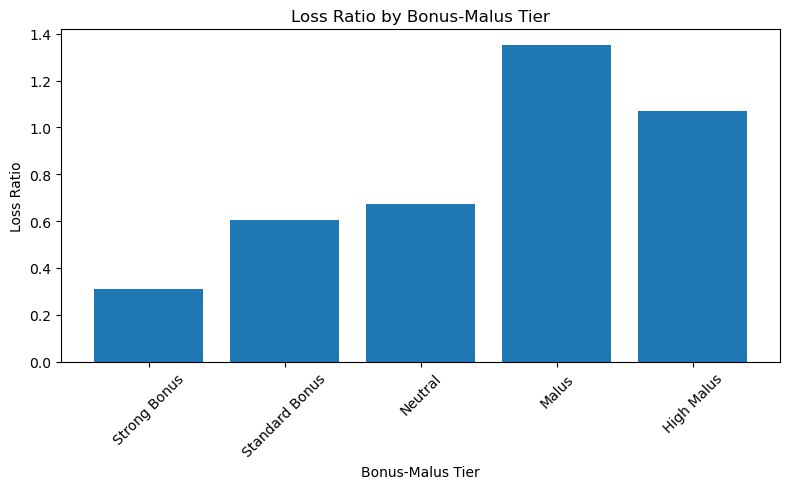

In [200]:
bonus_malus_plot = bonus_malus_summary.sort_values("bonus_malus_tier")

plt.figure(figsize=(8, 5))
plt.bar(bonus_malus_plot["bonus_malus_tier"].astype(str), bonus_malus_plot["loss_ratio"])
plt.title("Loss Ratio by Bonus-Malus Tier")
plt.xlabel("Bonus-Malus Tier")
plt.ylabel("Loss Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

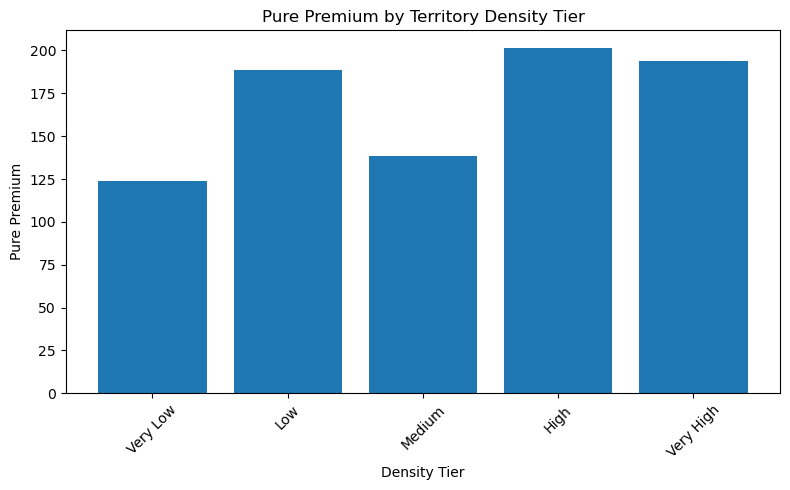

In [201]:
density_plot = density_summary.sort_values("density_tier")

plt.figure(figsize=(8, 5))
plt.bar(density_plot["density_tier"].astype(str), density_plot["pure_premium"])
plt.title("Pure Premium by Territory Density Tier")
plt.xlabel("Density Tier")
plt.ylabel("Pure Premium")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Rating Feature Insights

The rating-feature analysis shows that claim frequency, pure premium, and loss ratio vary across driver age, vehicle age, Bonus-Malus tier, and territory density. These differences indicate that rating features are useful for segmenting policy risk and monitoring product performance.

Bonus-Malus and territory density are especially useful for reporting because they help separate higher-risk and lower-risk policy groups. From a Product Analyst perspective, these segments should be monitored regularly through recurring KPI reports rather than viewed as one-time analysis.

The goal of this section is not to independently set insurance rates, but to identify which rating features should be reviewed by Product, State Management, and actuarial stakeholders.

In [202]:
# Exports
driver_age_summary.to_csv("outputs/tableau/driver_age_summary.csv", index=False)
vehicle_age_summary.to_csv("outputs/tableau/vehicle_age_summary.csv", index=False)
bonus_malus_summary.to_csv("outputs/tableau/bonus_malus_summary.csv", index=False)
density_summary.to_csv("outputs/tableau/density_summary.csv", index=False)
area_summary.to_csv("outputs/tableau/area_summary.csv", index=False)
region_summary.to_csv("outputs/tableau/region_summary.csv", index=False)

## Telematics Program Analysis

### Business Question

Is the telematics discount program attracting lower-risk drivers, improving retention, and creating acceptable product performance?

### Approach

I analyze eligibility, enrollment, driving score tiers, discount distribution, premium impact, claim frequency, loss ratio, and retention. This section treats telematics as a product/rating program.

In [203]:
# telematics score tiers
policy_master["driving_score_tier"] = pd.cut(
    policy_master["driving_score"],
    bins=[-1, 59, 69, 79, 89, 100],
    labels=["<60 No Discount", "60-69 Watchlist", "70-79 Standard", "80-89 Safe", "90-100 Elite"]
)

policy_master["discount_tier"] = pd.cut(
    policy_master["expected_discount_percent"],
    bins=[-0.01, 0.00, 0.03, 0.08, 0.15, 0.20],
    labels=["0%", "3%", "8%", "15%", "20%"]
)

policy_master[[
    "IDpol",
    "telematics_eligible",
    "telematics_enrolled",
    "driving_score",
    "driving_score_tier",
    "expected_discount_percent",
    "discount_tier",
    "earned_premium",
    "premium_after_discount",
    "renewed"
]].head()

,IDpol,telematics_eligible,telematics_enrolled,driving_score,driving_score_tier,expected_discount_percent,discount_tier,earned_premium,premium_after_discount,renewed
0,1.0,1,0,NaN,NaN,0.00,0%,100.000000,100.000000,1
1,3.0,1,0,NaN,NaN,0.00,0%,287.040563,287.040563,1
2,5.0,1,0,NaN,NaN,0.00,0%,262.967671,262.967671,0
3,10.0,1,0,NaN,NaN,0.00,0%,100.000000,100.000000,1
4,11.0,1,1,71.494024,70-79 Standard,0.08,8%,281.944978,259.389380,1


In [204]:
# overall telematics KPIs
eligible_policies = policy_master[policy_master["telematics_eligible"] == 1]
enrolled_policies = policy_master[policy_master["telematics_enrolled"] == 1]

telematics_kpis = pd.DataFrame({
    "metric": [
        "Total Policies",
        "Eligible Policies",
        "Enrolled Policies",
        "Eligibility Rate",
        "Enrollment Rate Among Eligible",
        "Average Driving Score",
        "Average Discount",
        "Total Premium Before Discount",
        "Total Premium After Discount",
        "Total Discount Amount",
        "Retention Rate - Enrolled",
        "Retention Rate - Not Enrolled"
    ],
    "value": [
        len(policy_master),
        len(eligible_policies),
        len(enrolled_policies),
        policy_master["telematics_eligible"].mean(),
        eligible_policies["telematics_enrolled"].mean(),
        enrolled_policies["driving_score"].mean(),
        enrolled_policies["expected_discount_percent"].mean(),
        enrolled_policies["earned_premium"].sum(),
        enrolled_policies["premium_after_discount"].sum(),
        (enrolled_policies["earned_premium"] - enrolled_policies["premium_after_discount"]).sum(),
        policy_master.loc[policy_master["telematics_enrolled"] == 1, "renewed"].mean(),
        policy_master.loc[policy_master["telematics_enrolled"] == 0, "renewed"].mean()
    ]
})

display(telematics_kpis)

,metric,value
0,Total Policies,6.780130e+05
1,Eligible Policies,6.696910e+05
2,Enrolled Policies,2.339990e+05
3,Eligibility Rate,9.877259e-01
4,Enrollment Rate Among Eligible,3.494134e-01
5,Average Driving Score,7.782334e+01
6,Average Discount,1.035908e-01
7,Total Premium Before Discount,5.461198e+07
8,Total Premium After Discount,4.895398e+07
9,Total Discount Amount,5.658003e+06


In [205]:
# Enrollment vs non-enrollment performance
telematics_enrollment_summary = (
    policy_master.groupby("telematics_enrolled")
    .agg(
        policies=("IDpol", "count"),
        exposure=("Exposure", "sum"),
        claims=("ClaimNb", "sum"),
        total_claim_amount=("total_claim_amount", "sum"),
        earned_premium=("earned_premium", "sum"),
        premium_after_discount=("premium_after_discount", "sum"),
        avg_discount=("expected_discount_percent", "mean"),
        retention_rate=("renewed", "mean")
    )
    .reset_index()
)

telematics_enrollment_summary["claim_frequency"] = (
    telematics_enrollment_summary["claims"] / telematics_enrollment_summary["exposure"]
)

telematics_enrollment_summary["claim_severity"] = np.where(
    telematics_enrollment_summary["claims"] > 0,
    telematics_enrollment_summary["total_claim_amount"] / telematics_enrollment_summary["claims"],
    0
)

telematics_enrollment_summary["loss_ratio_before_discount"] = (
    telematics_enrollment_summary["total_claim_amount"] / telematics_enrollment_summary["earned_premium"]
)

telematics_enrollment_summary["loss_ratio_after_discount"] = (
    telematics_enrollment_summary["total_claim_amount"] / telematics_enrollment_summary["premium_after_discount"]
)

display(telematics_enrollment_summary)

,telematics_enrolled,policies,exposure,claims,total_claim_amount,earned_premium,premium_after_discount,avg_discount,retention_rate,claim_frequency,claim_severity,loss_ratio_before_discount,loss_ratio_after_discount
0,0,444014,235062.138923,23715,38644210.49,1.037242e+08,1.037242e+08,0.000000,0.778286,0.100888,1629.526059,0.372567,0.372567
1,1,233999,123437.306539,12387,21265006.01,5.461198e+07,4.895398e+07,0.103591,0.838816,0.100351,1716.719626,0.389384,0.434388


In [206]:
# performance by driving score tier
score_tier_summary = (
    policy_master[policy_master["telematics_enrolled"] == 1]
    .groupby("driving_score_tier", observed=True)
    .agg(
        policies=("IDpol", "count"),
        exposure=("Exposure", "sum"),
        claims=("ClaimNb", "sum"),
        total_claim_amount=("total_claim_amount", "sum"),
        earned_premium=("earned_premium", "sum"),
        premium_after_discount=("premium_after_discount", "sum"),
        avg_driving_score=("driving_score", "mean"),
        avg_discount=("expected_discount_percent", "mean"),
        retention_rate=("renewed", "mean")
    )
    .reset_index()
)

score_tier_summary["claim_frequency"] = score_tier_summary["claims"] / score_tier_summary["exposure"]

score_tier_summary["claim_severity"] = np.where(
    score_tier_summary["claims"] > 0,
    score_tier_summary["total_claim_amount"] / score_tier_summary["claims"],
    0
)

score_tier_summary["loss_ratio_before_discount"] = (
    score_tier_summary["total_claim_amount"] / score_tier_summary["earned_premium"]
)

score_tier_summary["loss_ratio_after_discount"] = (
    score_tier_summary["total_claim_amount"] / score_tier_summary["premium_after_discount"]
)

display(score_tier_summary)

,driving_score_tier,policies,exposure,claims,total_claim_amount,earned_premium,premium_after_discount,avg_driving_score,avg_discount,retention_rate,claim_frequency,claim_severity,loss_ratio_before_discount,loss_ratio_after_discount
0,<60 No Discount,13339,7034.972004,736,1051162.44,3.134365e+06,3.134365e+06,53.783242,0.000000,0.833646,0.104620,1428.209837,0.335367,0.335367
1,60-69 Watchlist,39832,21029.091288,2075,6473542.63,9.295069e+06,9.032443e+06,64.790913,0.028253,0.841509,0.098673,3119.779581,0.696449,0.716699
2,70-79 Standard,71691,37826.100579,3767,5845997.30,1.670373e+07,1.543725e+07,74.224853,0.075824,0.837344,0.099587,1551.897345,0.349982,0.378694
3,80-89 Safe,67277,35494.410993,3597,4792842.66,1.569215e+07,1.346372e+07,83.675203,0.141952,0.838949,0.101340,1332.455563,0.305429,0.355982
4,90-100 Elite,41860,22052.731675,2212,3101460.98,9.786670e+06,7.886204e+06,94.642807,0.194190,0.840205,0.100305,1402.107134,0.316907,0.393277


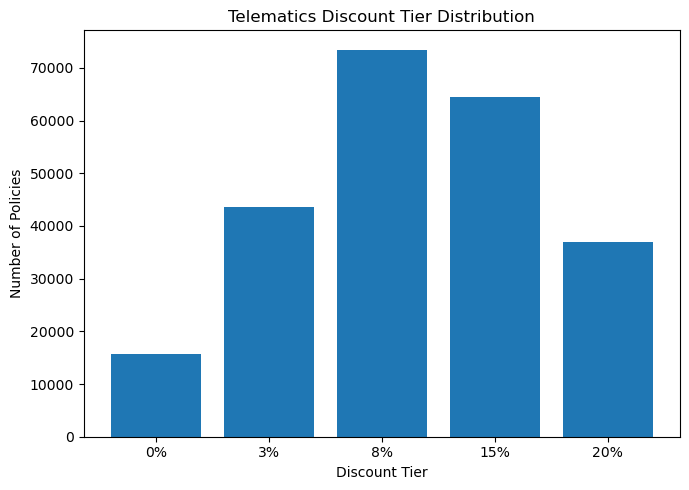

In [207]:
# discount tier distribution chart
discount_distribution = (
    policy_master[policy_master["telematics_enrolled"] == 1]
    .groupby("discount_tier", observed=True)
    .agg(policies=("IDpol", "count"))
    .reset_index()
)

plt.figure(figsize=(7, 5))
plt.bar(
    discount_distribution["discount_tier"].astype(str),
    discount_distribution["policies"]
)

plt.title("Telematics Discount Tier Distribution")
plt.xlabel("Discount Tier")
plt.ylabel("Number of Policies")
plt.tight_layout()
plt.show()

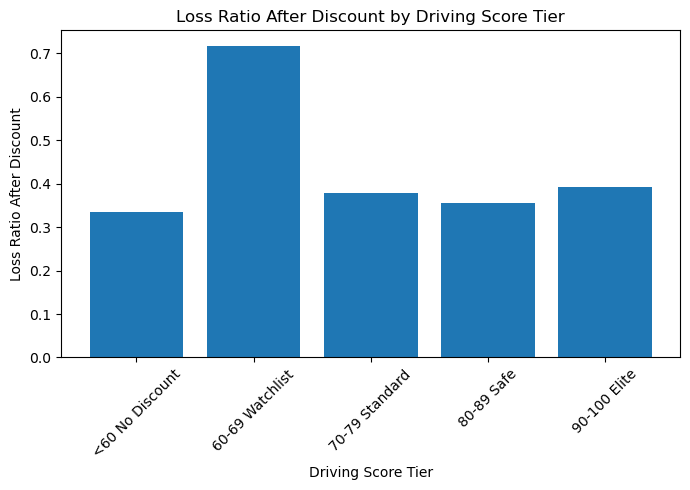

In [208]:
# Loss ratio by driving score tier
score_tier_plot = score_tier_summary.sort_values("driving_score_tier")

plt.figure(figsize=(7, 5))
plt.bar(
    score_tier_plot["driving_score_tier"].astype(str),
    score_tier_plot["loss_ratio_after_discount"]
)

plt.title("Loss Ratio After Discount by Driving Score Tier")
plt.xlabel("Driving Score Tier")
plt.ylabel("Loss Ratio After Discount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

note: the loss ratio tier is not ideal. The 60-69 Watchlist tier has the highest loss ratio, which is fine, but the <60 No Discount tier is lower than expected. Also 90-100 Elite is not clearly the best. That happens because your driving_score was simulated mostly randomly

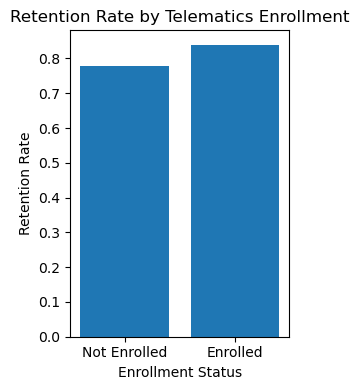

In [209]:
# Retention by telematics enrollment
retention_plot = telematics_enrollment_summary.copy()
retention_plot["enrollment_status"] = retention_plot["telematics_enrolled"].map({
    0: "Not Enrolled",
    1: "Enrolled"
})

plt.figure(figsize=(3, 4))
plt.bar(
    retention_plot["enrollment_status"],
    retention_plot["retention_rate"]
)

plt.title("Retention Rate by Telematics Enrollment")
plt.xlabel("Enrollment Status")
plt.ylabel("Retention Rate")
plt.tight_layout()
plt.show()

### Telematics Program Insights

The telematics program creates a clear product analytics framework: eligibility measures the addressable population, enrollment measures activation, driving score represents engagement, discount tier measures program value, and renewal measures retention.

The program should be monitored using both customer adoption metrics and insurance performance metrics. Enrollment alone is not enough; Product and State Management should also review claim frequency, loss ratio before and after discount, and retention by score tier.

From an implementation perspective, the driving score to discount mapping creates a clear rule set that can be tested in the UAT section. This connects product analytics with implementation validation.

In [210]:
# exports
telematics_kpis.to_csv("outputs/tableau/telematics_kpis.csv", index=False)
telematics_enrollment_summary.to_csv("outputs/tableau/telematics_enrollment_summary.csv", index=False)
score_tier_summary.to_csv("outputs/tableau/telematics_score_tier_summary.csv", index=False)
discount_distribution.to_csv("outputs/tableau/telematics_discount_distribution.csv", index=False)

## Implementation Testing and UAT

### Business Question

Were telematics discount rules implemented correctly across eligible policies, score tiers, edge cases, and premium calculations?

### Objective

This section creates a UAT-style testing framework for the telematics discount program. I compare expected discount outputs against simulated actual system outputs, identify pass/fail results, and summarize implementation issues.

In [214]:
# Define telematics business rules
def expected_telematics_discount(row):
    score = row["driving_score"]

    if row["telematics_eligible"] != 1:
        return 0.00
    
    if row["telematics_enrolled"] != 1:
        return 0.00
    
    if pd.isna(score):
        return 0.00
    
    if score < 0 or score > 100:
        return np.nan
    
    if score >= 90:
        return 0.20
    elif score >= 80:
        return 0.15
    elif score >= 70:
        return 0.08
    elif score >= 60:
        return 0.03
    else:
        return 0.00

In [219]:
uat_policy_sample = policy_master.copy()

uat_policy_sample["uat_expected_discount"] = uat_policy_sample.apply(
    expected_telematics_discount,
    axis=1
)

uat_policy_sample["uat_expected_premium_after_discount"] = (
    uat_policy_sample["earned_premium"] 
    * (1 - uat_policy_sample["uat_expected_discount"].fillna(0))
)

uat_policy_sample[[
    "IDpol",
    "telematics_eligible",
    "telematics_enrolled",
    "driving_score",
    "earned_premium",
    "uat_expected_discount",
    "uat_expected_premium_after_discount"
]].head()

,IDpol,telematics_eligible,telematics_enrolled,driving_score,earned_premium,uat_expected_discount,uat_expected_premium_after_discount
0,1.0,1,0,NaN,100.000000,0.00,100.000000
1,3.0,1,0,NaN,287.040563,0.00,287.040563
2,5.0,1,0,NaN,262.967671,0.00,262.967671
3,10.0,1,0,NaN,100.000000,0.00,100.000000
4,11.0,1,1,71.494024,281.944978,0.08,259.389380


In [220]:
# Simulate actual system output
np.random.seed(42)

uat_policy_sample["actual_discount"] = uat_policy_sample["uat_expected_discount"]

# Inject small number of intentional implementation errors for UAT detection
eligible_enrolled_idx = uat_policy_sample[
    (uat_policy_sample["telematics_eligible"] == 1) &
    (uat_policy_sample["telematics_enrolled"] == 1)
].sample(500, random_state=42).index

uat_policy_sample.loc[eligible_enrolled_idx, "actual_discount"] = np.random.choice(
    [0.00, 0.03, 0.08, 0.15, 0.20],
    size=len(eligible_enrolled_idx)
)

uat_policy_sample["actual_premium_after_discount"] = (
    uat_policy_sample["earned_premium"] 
    * (1 - uat_policy_sample["actual_discount"].fillna(0))
)

In [222]:
# Compare expected vs actual
uat_policy_sample["discount_match"] = np.isclose(
    uat_policy_sample["uat_expected_discount"],
    uat_policy_sample["actual_discount"],
    equal_nan=True
)

uat_policy_sample["premium_match"] = np.isclose(
    uat_policy_sample["uat_expected_premium_after_discount"],
    uat_policy_sample["actual_premium_after_discount"],
    rtol=0.001
)

uat_policy_sample["uat_status"] = np.where(
    uat_policy_sample["discount_match"] & uat_policy_sample["premium_match"],
    "Pass",
    "Fail"
)

uat_policy_sample[[
    "IDpol",
    "driving_score",
    "uat_expected_discount",
    "actual_discount",
    "uat_expected_premium_after_discount",
    "actual_premium_after_discount",
    "uat_status"
]].head()

,IDpol,driving_score,uat_expected_discount,actual_discount,uat_expected_premium_after_discount,actual_premium_after_discount,uat_status
0,1.0,NaN,0.00,0.00,100.000000,100.000000,Pass
1,3.0,NaN,0.00,0.00,287.040563,287.040563,Pass
2,5.0,NaN,0.00,0.00,262.967671,262.967671,Pass
3,10.0,NaN,0.00,0.00,100.000000,100.000000,Pass
4,11.0,71.494024,0.08,0.08,259.389380,259.389380,Pass


In [223]:
# Create Issue type
def assign_uat_issue_type(row):
    if row["uat_status"] == "Pass":
        return "No Issue"
    
    if not row["discount_match"]:
        return "Discount Rule Mismatch"
    
    if not row["premium_match"]:
        return "Premium Calculation Mismatch"
    
    return "Other UAT Issue"

uat_policy_sample["issue_type"] = uat_policy_sample.apply(
    assign_uat_issue_type,
    axis=1
)

uat_failures = uat_policy_sample[uat_policy_sample["uat_status"] == "Fail"]

display(uat_failures[[
    "IDpol",
    "telematics_eligible",
    "telematics_enrolled",
    "driving_score",
    "uat_expected_discount",
    "actual_discount",
    "uat_status",
    "issue_type"
]].head(20))

,IDpol,telematics_eligible,telematics_enrolled,driving_score,uat_expected_discount,actual_discount,uat_status,issue_type
1903,3959.0,1,1,70.958253,0.08,0.15,Fail,Discount Rule Mismatch
2270,4733.0,1,1,70.781072,0.08,0.15,Fail,Discount Rule Mismatch
2290,4772.0,1,1,63.572594,0.03,0.00,Fail,Discount Rule Mismatch
2530,5273.0,1,1,94.166682,0.20,0.15,Fail,Discount Rule Mismatch
3329,6975.0,1,1,84.401177,0.15,0.00,Fail,Discount Rule Mismatch
6210,18835.0,1,1,79.310257,0.08,0.20,Fail,Discount Rule Mismatch
6488,19368.0,1,1,72.446292,0.08,0.20,Fail,Discount Rule Mismatch
7167,20688.0,1,1,46.791321,0.00,0.15,Fail,Discount Rule Mismatch
8562,23359.0,1,1,89.445896,0.15,0.08,Fail,Discount Rule Mismatch
8644,23514.0,1,1,73.216357,0.08,0.15,Fail,Discount Rule Mismatch


In [228]:
# UAT Summary table
uat_summary = (
    uat_policy_sample
    .groupby(["uat_status", "issue_type"])
    .agg(
        records=("IDpol", "count")
    )
    .reset_index()
)

total_records = len(uat_policy_sample)
passed_records = (uat_policy_sample["uat_status"] == "Pass").sum()
failed_records = (uat_policy_sample["uat_status"] == "Fail").sum()
pass_rate = passed_records / total_records

uat_overall_summary = pd.DataFrame({
    "metric": [
        "Total Records Tested",
        "Passed Records",
        "Failed Records",
        "Pass Rate"
    ],
    "value": [
        total_records,
        passed_records,
        failed_records,
        pass_rate
    ]
})

display(uat_overall_summary)
display(uat_summary)

,metric,value
0,Total Records Tested,678013.000000
1,Passed Records,677628.000000
2,Failed Records,385.000000
3,Pass Rate,0.999432


,uat_status,issue_type,records
0,Fail,Discount Rule Mismatch,385
1,Pass,No Issue,677628


In [229]:
# Edge case test case
edge_cases = pd.DataFrame({
    "test_case": [
        "Ineligible policy with high score",
        "Eligible but not enrolled",
        "Missing score",
        "Invalid score above 100",
        "Invalid score below 0",
        "Boundary score 90",
        "Boundary score 89.99",
        "Boundary score 80",
        "Boundary score 79.99",
        "Boundary score 70",
        "Boundary score 69.99",
        "Boundary score 60",
        "Boundary score 59.99"
    ],
    "telematics_eligible": [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    "telematics_enrolled": [1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    "driving_score": [95, 95, np.nan, 101, -5, 90, 89.99, 80, 79.99, 70, 69.99, 60, 59.99],
    "earned_premium": [1000] * 13
})

edge_cases["expected_discount"] = edge_cases.apply(
    expected_telematics_discount,
    axis=1
)

edge_cases["expected_premium_after_discount"] = (
    edge_cases["earned_premium"] 
    * (1 - edge_cases["expected_discount"].fillna(0))
)

display(edge_cases)

,test_case,telematics_eligible,telematics_enrolled,driving_score,earned_premium,expected_discount,expected_premium_after_discount
0,Ineligible policy with high score,0,1,95.00,1000,0.00,1000.0
1,Eligible but not enrolled,1,0,95.00,1000,0.00,1000.0
2,Missing score,1,1,NaN,1000,0.00,1000.0
3,Invalid score above 100,1,1,101.00,1000,NaN,1000.0
4,Invalid score below 0,1,1,-5.00,1000,NaN,1000.0
5,Boundary score 90,1,1,90.00,1000,0.20,800.0
6,Boundary score 89.99,1,1,89.99,1000,0.15,850.0
7,Boundary score 80,1,1,80.00,1000,0.15,850.0
8,Boundary score 79.99,1,1,79.99,1000,0.08,920.0
9,Boundary score 70,1,1,70.00,1000,0.08,920.0


The UAT test reviewed 678,013 policy records and identified 385 discount-rule mismatches, resulting in a 99.94% pass rate. All failed records were tied to incorrect discount tier assignment, indicating that the premium calculation logic worked when the correct discount was applied, but the score-to-discount mapping requires IT/Product review before launch.

In [233]:
# exports 
uat_policy_sample.to_csv("outputs/tableau/uat_policy_test_results.csv", index=False)
uat_summary.to_csv("outputs/tableau/uat_summary.csv", index=False)
uat_overall_summary.to_csv("outputs/tableau/uat_overall_summary.csv", index=False)
edge_cases.to_csv("outputs/tableau/uat_edge_cases.csv", index=False)
uat_failures.to_csv("outputs/Tableau/uat_failed_records.csv", index=False)

### UAT Testing Insights

The UAT framework validates whether telematics discount rules were applied correctly across the policy dataset. The test compares expected discounts from the business rules against actual system outputs and flags mismatches for review.

This type of testing is important before a product or rating change goes live because incorrect discount logic can affect premium, customer experience, reporting accuracy, and profitability.

The edge case tests validate boundary scores such as 90, 80, 70, and 60, along with missing or invalid scores. These cases are especially important because product implementation errors often occur around cutoff rules.

## Project Summary

### Project Objective

This project evaluated rating-feature performance and a simulated telematics discount program for a personal auto insurance product. The goal was to analyze product performance, monitor rating variables, evaluate telematics program impact, and test whether discount rules were implemented correctly before launch.

### Key Findings

1. Driver age showed clear differences in claim frequency, with younger drivers producing materially higher claim frequency than older driver segments.

2. Rating features such as driver age, vehicle age, Bonus-Malus tier, territory density, area, and region can be used to monitor claim frequency, pure premium, severity, and loss ratio across product segments.

3. The telematics program had strong simulated adoption, with roughly 35% enrollment among eligible policies and an average driving score near 78.

4. Telematics discounts reduced premium for enrolled customers, creating a need to monitor loss ratio before and after discount by driving score tier.

5. Enrolled telematics customers showed higher simulated retention than non-enrolled customers, suggesting potential customer value from the program.

6. UAT testing reviewed 678,013 policy records and found 385 discount-rule mismatches, resulting in a 99.94% pass rate.

7. All UAT failures were tied to discount rule mismatches, meaning the key issue was score-to-discount mapping rather than the premium calculation formula.

### Recommendation

The insurer should continue monitoring rating-feature performance through recurring KPI reports, especially claim frequency, pure premium, and loss ratio by driver age, Bonus-Malus tier, and territory. The telematics program should be tracked using both adoption metrics and insurance performance metrics, including enrollment rate, discount impact, loss ratio after discount, and retention.

Before production launch, Product and IT should review the failed UAT cases to correct discount tier mapping logic, especially around driving score bands and edge cases. Once implementation rules are validated, the program can be monitored through Tableau dashboards using the exported rating-feature, telematics, and UAT summary files.